# CCS3356 – Sentiment Analysis of Customer Reviews
## Member 02 – M S M Simak (CIT-24-01-0010)
**ML Model:** Support Vector Machine (SVM)
**DL Model:** GRU (Gated Recurrent Unit)

**Pipeline:** Data Cleaning → Lowercase Conversion → Tokenization → Stop Word Removal → Stemming → Vectorization → Model Training → Evaluation


In [1]:
import sys, re, time
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_utils import load_dataset, get_split, RANDOM_STATE

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_recall_fscore_support)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


I0000 00:00:1786825169.244663    1141 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786825169.317227    1141 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786825170.756128    1141 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Data Collection

In [2]:
df = load_dataset('../data/1429_1.csv')
print('Shape:', df.shape)
df.head()


Shape: (34626, 6)


/home/claude/NLP-Sentiment-Analysis-Group12/notebooks/../src/data_utils.py:46: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,id,name,rating,review_text,review_title,sentiment
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,This product so far has not disappointed. My c...,Kindle,Positive
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,great for beginner or experienced person. Boug...,very fast,Positive
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,Positive
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,Positive
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,Positive


## 2. Data Cleaning & Lowercase Conversion
Removes noise, missing values, special characters, and irrelevant information; converts
all text to lowercase to ensure consistency and prevent duplicate word representations.

In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['review_text'].apply(clean_text)
df[['review_text', 'clean_text']].head(3)


,review_text,clean_text
0,This product so far has not disappointed. My c...,this product so far has not disappointed my ch...
1,great for beginner or experienced person. Boug...,great for beginner or experienced person bough...
2,Inexpensive tablet for him to use and learn on...,inexpensive tablet for him to use and learn on...


## 3. Tokenization, Stop Word Removal & Stemming
Stemming (Porter Stemmer) reduces words to their root forms, allowing similar words to
be treated as a single feature — different from Member 1's lemmatization approach.

In [4]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def tokenize_stem(text):
    tokens = text.split()
    tokens = [stemmer.stem(tok) for tok in tokens if tok not in stop_words and len(tok) > 2]
    return tokens

t0 = time.time()
df['tokens'] = df['clean_text'].apply(tokenize_stem)
df['processed_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))
print(f'Preprocessing done in {time.time()-t0:.1f}s')
df[['processed_text']].head(3)


Preprocessing done in 6.5s


,processed_text
0,product far disappoint children love use like ...
1,great beginn experienc person bought gift love
2,inexpens tablet use learn step nabi thrill lea...


### Class Distribution (EDA)

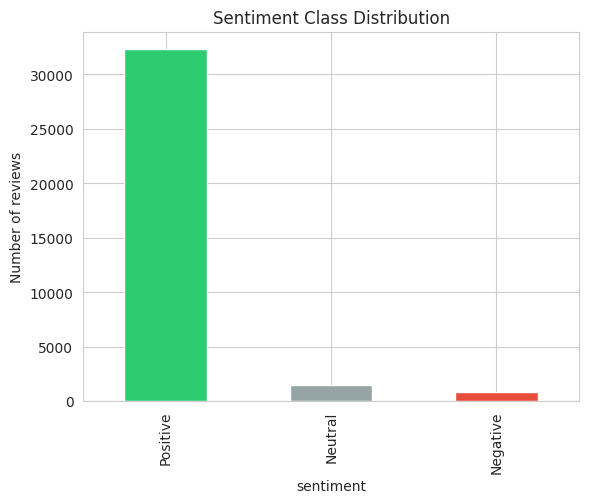

In [5]:
df['sentiment'].value_counts().plot(kind='bar', color=['#2ecc71','#95a5a6','#e74c3c'])
plt.title('Sentiment Class Distribution')
plt.ylabel('Number of reviews')
plt.show()


## 4. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = get_split(df, text_col='processed_text', label_col='sentiment')
print(X_train.shape, X_test.shape)


(27700,) (6926,)


## 5. Vectorization (Bag-of-Words / CountVectorizer)
Transforms textual data into numerical representations that machine learning algorithms
can understand. A Bag-of-Words count representation is used here (distinct from
Member 1's TF-IDF weighting) to give the group a comparison across feature-extraction
strategies as well as models.

In [7]:
vectorizer = CountVectorizer(max_features=8000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print('Vectorized matrix shape:', X_train_vec.shape)


Vectorized matrix shape: (27700, 8000)


## 6. ML Model – Support Vector Machine (SVM)
SVM performs exceptionally well in high-dimensional text classification problems and has
proven effectiveness in sentiment analysis applications. `LinearSVC` is used for
efficiency on a high-dimensional sparse feature matrix, wrapped with
`CalibratedClassifierCV` so we can also report probability-based metrics.

In [8]:
svm = CalibratedClassifierCV(LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000))
t0 = time.time()
svm.fit(X_train_vec, y_train)
print(f'SVM trained in {time.time()-t0:.1f}s')


SVM trained in 51.3s


Accuracy: 0.9354605833092694
              precision    recall  f1-score   support

    Negative       0.70      0.09      0.15       162
     Neutral       0.80      0.01      0.03       300
    Positive       0.94      1.00      0.97      6464

    accuracy                           0.94      6926
   macro avg       0.81      0.37      0.38      6926
weighted avg       0.92      0.94      0.91      6926



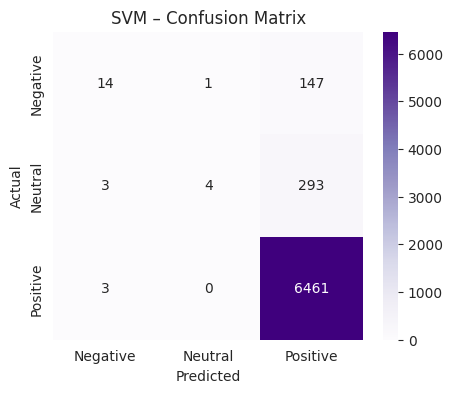

In [9]:
y_pred_svm = svm.predict(X_test_vec)
print('Accuracy:', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm, labels=['Negative','Neutral','Positive'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('SVM – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


## 7. DL Model – GRU (Gated Recurrent Unit)
GRU offers performance similar to LSTM while requiring fewer parameters and shorter
training times, thanks to its simplified gating mechanism (reset and update gates only).

In [10]:
MAX_WORDS = 10000
MAX_LEN = 100

label_map = {'Negative':0, 'Neutral':1, 'Positive':2}
inv_label_map = {v:k for k,v in label_map.items()}
y_train_int = y_train.map(label_map).values
y_test_int = y_test.map(label_map).values
y_train_cat = to_categorical(y_train_int, num_classes=3)
y_test_cat = to_categorical(y_test_int, num_classes=3)

keras_tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train)
X_train_seq = pad_sequences(keras_tok.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(keras_tok.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post', truncating='post')
print(X_train_seq.shape, X_test_seq.shape)


(27700, 100) (6926, 100)


In [11]:
gru_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    GRU(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
gru_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train_int)
# Dampen extreme weights (sqrt) so gradient-based training doesn't over-correct
cw = np.sqrt(cw)
class_weight_dict = {i: w for i, w in enumerate(cw)}

history = gru_model.fit(
    X_train_seq, y_train_cat,
    validation_split=0.1,
    epochs=4, batch_size=128,
    class_weight=class_weight_dict,
    verbose=2
)


Epoch 1/4


195/195 - 27s - 137ms/step - accuracy: 0.9297 - loss: 0.6164 - val_accuracy: 0.9357 - val_loss: 0.4832


Epoch 2/4


195/195 - 41s - 209ms/step - accuracy: 0.9330 - loss: 0.6053 - val_accuracy: 0.9357 - val_loss: 0.4811


Epoch 3/4


195/195 - 41s - 210ms/step - accuracy: 0.9330 - loss: 0.6020 - val_accuracy: 0.9357 - val_loss: 0.4657


Epoch 4/4


195/195 - 41s - 210ms/step - accuracy: 0.9330 - loss: 0.5994 - val_accuracy: 0.9357 - val_loss: 0.4822


Accuracy: 0.9332948310713255
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       162
     Neutral       0.00      0.00      0.00       300
    Positive       0.93      1.00      0.97      6464

    accuracy                           0.93      6926
   macro avg       0.31      0.33      0.32      6926
weighted avg       0.87      0.93      0.90      6926



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


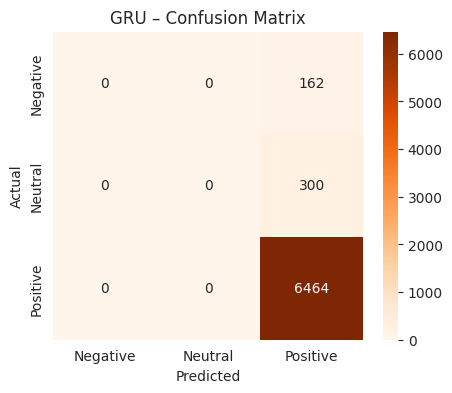

In [13]:
y_pred_gru_prob = gru_model.predict(X_test_seq, verbose=0)
y_pred_gru = np.argmax(y_pred_gru_prob, axis=1)
y_pred_gru_labels = [inv_label_map[i] for i in y_pred_gru]

print('Accuracy:', accuracy_score(y_test, y_pred_gru_labels))
print(classification_report(y_test, y_pred_gru_labels))

cm2 = confusion_matrix(y_test, y_pred_gru_labels, labels=['Negative','Neutral','Positive'])
plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('GRU – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


## 8. Model Comparison – SVM vs GRU

In [14]:
def macro_scores(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return accuracy_score(y_true, y_pred), p, r, f1

acc_svm, p_svm, r_svm, f1_svm = macro_scores(y_test, y_pred_svm)
acc_gru, p_gru, r_gru, f1_gru = macro_scores(y_test, y_pred_gru_labels)

comparison = pd.DataFrame({
    'Model': ['SVM (ML)', 'GRU (DL)'],
    'Accuracy': [acc_svm, acc_gru],
    'Macro Precision': [p_svm, p_gru],
    'Macro Recall': [r_svm, r_gru],
    'Macro F1': [f1_svm, f1_gru],
})
comparison


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,SVM (ML),0.935461,0.812080,0.366430,0.382310
1,GRU (DL),0.933295,0.311098,0.333333,0.321832


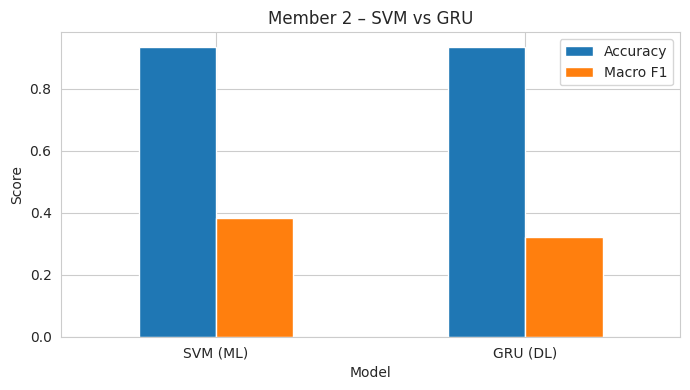

In [15]:
comparison.set_index('Model')[['Accuracy','Macro F1']].plot(kind='bar', figsize=(7,4))
plt.title('Member 2 – SVM vs GRU')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Save Models

In [16]:
import joblib, os, pickle
os.makedirs('../models', exist_ok=True)
joblib.dump(svm, '../models/simak_svm.joblib')
joblib.dump(vectorizer, '../models/simak_count_vectorizer.joblib')
gru_model.save('../models/simak_gru_model.keras')
with open('../models/simak_keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(keras_tok, f)
print('Saved: svm, count_vectorizer, gru_model, keras_tokenizer')


Saved: svm, count_vectorizer, gru_model, keras_tokenizer


## Contribution Summary (Simak)
- Data cleaning
- SVM implementation
- GRU model development
- Experimental analysis
- Report writing
